# **PROYECTO SCOTIABANK UTILIZANDO PYSPARK PARA GRANDES VOLUMNES DE DATOS, PANDAS PARA GRAFICAR Y  SQL PARA CONSULTAS BASICAS**

La limpieza y validación de los datos se hizo mediante PowerQuery de Power BI, pasando a un archivo CSV de Excel para ser cargados y analizados por las herramientas de Pyspark, Pandas y SQL.

Se crearán tablas y datos, para generar un modelo, posteriormente se llevará a POWER BI para la realización de tableros.


**Objetivo:**\
Utilizando la base de datos adjunta (csv) con información de ventas mensuales de
hipotecas para el sistema bancario mexicano, tu objetivo como Consultor de Market Intelligence es procesar esta base para encontrar insights relevantes y oportunidades de mercado para Scotiabank.

**Descripción de la Base de Datos:**\
La base de datos contiene información agregada a nivel mensual sobre las hipotecas
otorgadas por diferentes bancos en México. Cada fila representa el monto promedio de
crédito, junto con otras características, para un grupo de personas que comparten las
mismas variables categóricas (estado, tipo de acreditado, género, etc.).

**Estructura de la Base de Datos (limpios):**

**Variables categóricas:**

*   Periodo: periodo
*   Banco: nombre de banco
*   Estado
*  Tipo_acreditado :  público o privado
*   Tipo_comprobacion: Asalariado o no asalariado
*  Genero: Género
*  destino_credito: destino del credito

**Variables númericas:**

* Ingreso_mensual_bruto
* Valor_vivienda
* Edad_acred
* Monto_credito: valor del monto del crédito otorgado
* tasa_ponderada

**ANÁLISIS REQUERIDO:**


## 1. **Participación de mercado de Scotiabank (Nov23):**

 Determina la participación de Scotiabank en el mercado de originación de hipotecas a nivel nacional en noviembre 2023.

In [ ]:
# -*- coding: utf-8 -*-
"""
Se prepara el entorno de trabjo en Google Colab para iniciar con
 el análisis de los datos, utilizando Pyspark.

"""



In [1]:
# Modulo a iniciar / cargar

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Iniciar la seisón con Spark

spark = SparkSession.builder\
    .appName("Scotiabank")\
    .getOrCreate()


In [3]:
# Carga de datos y  confirmación del tipo de variables con Schema

Scotiabank_data = spark.read.csv(
    "/content/drive/MyDrive/DATOS PYSPARK/Hipotecario_limpio.csv",
    header = True,
    inferSchema=True,
    encoding="utf-8"
    )

#Visualización del schema o tipo de variables
Scotiabank_data.printSchema()

root
 |-- Sector: string (nullable = true)
 |-- Periodo: integer (nullable = true)
 |-- Banco: string (nullable = true)
 |-- Estado: string (nullable = true)
 |-- Municipio: string (nullable = true)
 |-- Tipo_acreditado: string (nullable = true)
 |-- Tipo_comprobacion: string (nullable = true)
 |-- Genero: string (nullable = true)
 |-- Destino_credito: string (nullable = true)
 |-- Ingreso_mensual_bruto: double (nullable = true)
 |-- Valor_vivienda: double (nullable = true)
 |-- Edad_acred: integer (nullable = true)
 |-- Monto_credito: double (nullable = true)
 |-- tasa_ponderada: double (nullable = true)



In [4]:
# Visualización y conteo de los datos

Scotiabank_data.show()
print(f"El número de observaciones es: {Scotiabank_data.count()}")

+--------------+-------+-----------+----------------+--------------+------------------+-----------------+---------+--------------------+---------------------+--------------+----------+-------------+--------------+
|        Sector|Periodo|      Banco|          Estado|     Municipio|   Tipo_acreditado|Tipo_comprobacion|   Genero|     Destino_credito|Ingreso_mensual_bruto|Valor_vivienda|Edad_acred|Monto_credito|tasa_ponderada|
+--------------+-------+-----------+----------------+--------------+------------------+-----------------+---------+--------------------+---------------------+--------------+----------+-------------+--------------+
|BANCA MÚLTIPLE| 202103|Banca Mifel|CIUDAD DE MÉXICO|ALVARO OBREGON|Asalariado Privado|       Asalariado|Masculino|Mejoras, Ampliaci...|               4123.0|      22158.41|        30|     22158.41|          17.0|
|BANCA MÚLTIPLE| 202103|Banca Mifel|CIUDAD DE MÉXICO|ALVARO OBREGON|Asalariado Privado|       Asalariado|Masculino|Mejoras, Ampliaci...|        

In [5]:

# Nombre de los bancos participantes

Scotiabank_data.select("Banco").distinct().orderBy("Banco")\
               .show(truncate=False)

+---------------+
|Banco          |
+---------------+
|Afirme         |
|Autofin        |
|BBVA México    |
|Banamex        |
|Banca Mifel    |
|Banco Azteca   |
|Banco del Bajío|
|Bancoppel      |
|Banorte        |
|Banregio       |
|Bansí          |
|CIBanco        |
|HSBC           |
|Inbursa        |
|Monex          |
|Multiva        |
|Santander      |
|Scotiabank     |
|Ve por Más     |
+---------------+



In [6]:
#Visualización y cambiar formato de fecha
""""
Dado que el formato esta en año y mes
nos interesa realizar el cambio a formato fecha
para un mejor análisis.
"""
from pyspark.sql.functions import col, concat, lit, to_date

Base = Scotiabank_data.withColumn(
    "Fecha",
    to_date(
        concat(col("Periodo"), lit("01")),
        "yyyyMMdd"
    )
)

Base.select("Periodo", "fecha").distinct()\
               .orderBy("Periodo", "fecha")\
               .show(100, truncate=False)


+-------+----------+
|Periodo|fecha     |
+-------+----------+
|201901 |2019-01-01|
|201902 |2019-02-01|
|201903 |2019-03-01|
|201904 |2019-04-01|
|201905 |2019-05-01|
|201906 |2019-06-01|
|201907 |2019-07-01|
|201908 |2019-08-01|
|201909 |2019-09-01|
|201910 |2019-10-01|
|201911 |2019-11-01|
|201912 |2019-12-01|
|202001 |2020-01-01|
|202002 |2020-02-01|
|202003 |2020-03-01|
|202004 |2020-04-01|
|202005 |2020-05-01|
|202006 |2020-06-01|
|202007 |2020-07-01|
|202008 |2020-08-01|
|202009 |2020-09-01|
|202010 |2020-10-01|
|202011 |2020-11-01|
|202012 |2020-12-01|
|202101 |2021-01-01|
|202102 |2021-02-01|
|202103 |2021-03-01|
|202104 |2021-04-01|
|202105 |2021-05-01|
|202106 |2021-06-01|
|202107 |2021-07-01|
|202108 |2021-08-01|
|202109 |2021-09-01|
|202110 |2021-10-01|
|202111 |2021-11-01|
|202112 |2021-12-01|
|202201 |2022-01-01|
|202202 |2022-02-01|
|202203 |2022-03-01|
|202204 |2022-04-01|
|202205 |2022-05-01|
|202206 |2022-06-01|
|202207 |2022-07-01|
|202208 |2022-08-01|
|202209 |2022

In [7]:
# Visualizamos nuevamente el tipo de variables para fecha

Base.printSchema()

root
 |-- Sector: string (nullable = true)
 |-- Periodo: integer (nullable = true)
 |-- Banco: string (nullable = true)
 |-- Estado: string (nullable = true)
 |-- Municipio: string (nullable = true)
 |-- Tipo_acreditado: string (nullable = true)
 |-- Tipo_comprobacion: string (nullable = true)
 |-- Genero: string (nullable = true)
 |-- Destino_credito: string (nullable = true)
 |-- Ingreso_mensual_bruto: double (nullable = true)
 |-- Valor_vivienda: double (nullable = true)
 |-- Edad_acred: integer (nullable = true)
 |-- Monto_credito: double (nullable = true)
 |-- tasa_ponderada: double (nullable = true)
 |-- Fecha: date (nullable = true)



In [8]:
# Creación de DATA FRAME PARA EL CALCULO DE PARTICIPACIÓN PORCENTUAL POR MES
# Y por banco
from pyspark.sql.functions import col, sum, round

#Monto total del mercado por mes

mercado_mes = Base.groupBy("Fecha")\
    .agg(
        sum("Monto_credito").cast(DecimalType(20,2)).alias("Monto_total")
    )

# Monto otorgado por banco y mes
banco_mes = Base.groupBy("Fecha", "Banco")\
    .agg(
        sum("Monto_credito").cast(DecimalType(20,2)).alias("Monto")
    )

# Unir y calcular participación
participacion = banco_mes.join(
    mercado_mes,
    on="Fecha",
    how="left"
).withColumn(
    "Part%",
    round(col("Monto") / col("Monto_total") * 100, 4)
).select(
    "Fecha",
    "Banco",
    "Monto",
    "Part%"
).orderBy(
    "Fecha",
    "Part%",
    ascending=[True, False]
)

participacion.show(truncate=False)



+----------+---------------+-------------+-------+
|Fecha     |Banco          |Monto        |Part%  |
+----------+---------------+-------------+-------+
|2019-01-01|Banorte        |1942651595.46|22.7254|
|2019-01-01|BBVA México    |1878941502.70|21.9801|
|2019-01-01|Scotiabank     |1571445662.90|18.3830|
|2019-01-01|HSBC           |1021784141.00|11.9530|
|2019-01-01|Banca Mifel    |910253365.89 |10.6483|
|2019-01-01|Banamex        |518719879.00 |6.0681 |
|2019-01-01|Ve por Más     |197830427.00 |2.3143 |
|2019-01-01|Multiva        |141684896.00 |1.6575 |
|2019-01-01|Santander      |110145795.00 |1.2885 |
|2019-01-01|Banregio       |99929958.10  |1.1690 |
|2019-01-01|CIBanco        |68038499.00  |0.7959 |
|2019-01-01|Autofin        |31200000.00  |0.3650 |
|2019-01-01|Banco del Bajío|28140011.00  |0.3292 |
|2019-01-01|Monex          |20805313.82  |0.2434 |
|2019-01-01|Bansí          |3500000.00   |0.0409 |
|2019-01-01|Inbursa        |3286634.80   |0.0384 |
|2019-02-01|Banorte        |235

In [ ]:
## PARTICIPACIÓN DE SCOTIABANK EN NOVIEMBRE 2023

participacion.filter((col("Fecha") == "2023-11-01") &
                      (col("Banco")== "Scotiabank")).show(truncate=False)

+----------+----------+-------------+-------+
|Fecha     |Banco     |Monto        |Part%  |
+----------+----------+-------------+-------+
|2023-11-01|Scotiabank|1974750212.48|15.3132|
+----------+----------+-------------+-------+



La participación de Scotiabank en el otorgamiento de créidto en Noviembre del 2023,  fue de $1, 974, 750,212.48. Esto representa el 15.3132% de participación porcentual a nivel nacional para ese periodo, respectivamente.

## **2. Evolución de la participación de mercado:**

Analiza cómo ha evolucionado la participación de mercado de Scotiabank a lo largo del tiempo identificando tendencias y cambios significativos.

In [ ]:
## Unicamente filtramos la tabla anterior con los datos de Scotiabnak,
#posteriormente convertimos la tabla a Pandas y graficamos

part_scotiabank = participacion.filter(col("Banco") == "Scotiabank")

part_scotiabank.show(100, truncate=False)

+----------+----------+-------------+-------+
|Fecha     |Banco     |Monto        |Part%  |
+----------+----------+-------------+-------+
|2019-01-01|Scotiabank|1571445662.90|18.3830|
|2019-02-01|Scotiabank|2167727676.00|23.0171|
|2019-03-01|Scotiabank|1980892138.87|16.9094|
|2019-04-01|Scotiabank|1798709728.07|17.9573|
|2019-05-01|Scotiabank|2068814672.72|16.8574|
|2019-06-01|Scotiabank|2151901663.30|19.0623|
|2019-07-01|Scotiabank|2645422949.66|21.9002|
|2019-08-01|Scotiabank|2872253678.98|23.3847|
|2019-09-01|Scotiabank|2949360150.13|25.6278|
|2019-10-01|Scotiabank|3152551115.14|24.8034|
|2019-11-01|Scotiabank|2605629770.78|22.4980|
|2019-12-01|Scotiabank|3563767823.29|23.9797|
|2020-01-01|Scotiabank|2017485162.12|20.7838|
|2020-02-01|Scotiabank|2699762235.67|24.0000|
|2020-03-01|Scotiabank|2907488541.17|22.7328|
|2020-04-01|Scotiabank|1945277136.87|22.9338|
|2020-05-01|Scotiabank|2015485594.64|22.2948|
|2020-06-01|Scotiabank|2122024584.55|21.0757|
|2020-07-01|Scotiabank|2578813958.

In [ ]:
## Se va a descargar la base de datos, posteriormente se carga a pandas
# para poder graficar
import pandas as pd

part_scotiabank.toPandas().to_csv(
    "/content/drive/MyDrive/DATOS PYSPARK/Participacion_Scotiabank.csv",
    index=False,
    encoding="utf-8")

df = pd.read_csv(
    "/content/drive/MyDrive/DATOS PYSPARK/Participacion_Scotiabank.csv",
    encoding="utf-8"
)

Datos_scotiabakn.head(10)



,Fecha,Banco,Monto,Part%
0,2019-01-01,Scotiabank,1.571446e+09,18.3830
1,2019-02-01,Scotiabank,2.167728e+09,23.0171
2,2019-03-01,Scotiabank,1.980892e+09,16.9094
3,2019-04-01,Scotiabank,1.798710e+09,17.9573
4,2019-05-01,Scotiabank,2.068815e+09,16.8574
5,2019-06-01,Scotiabank,2.151902e+09,19.0623
6,2019-07-01,Scotiabank,2.645423e+09,21.9002
7,2019-08-01,Scotiabank,2.872254e+09,23.3847
8,2019-09-01,Scotiabank,2.949360e+09,25.6278
9,2019-10-01,Scotiabank,3.152551e+09,24.8034


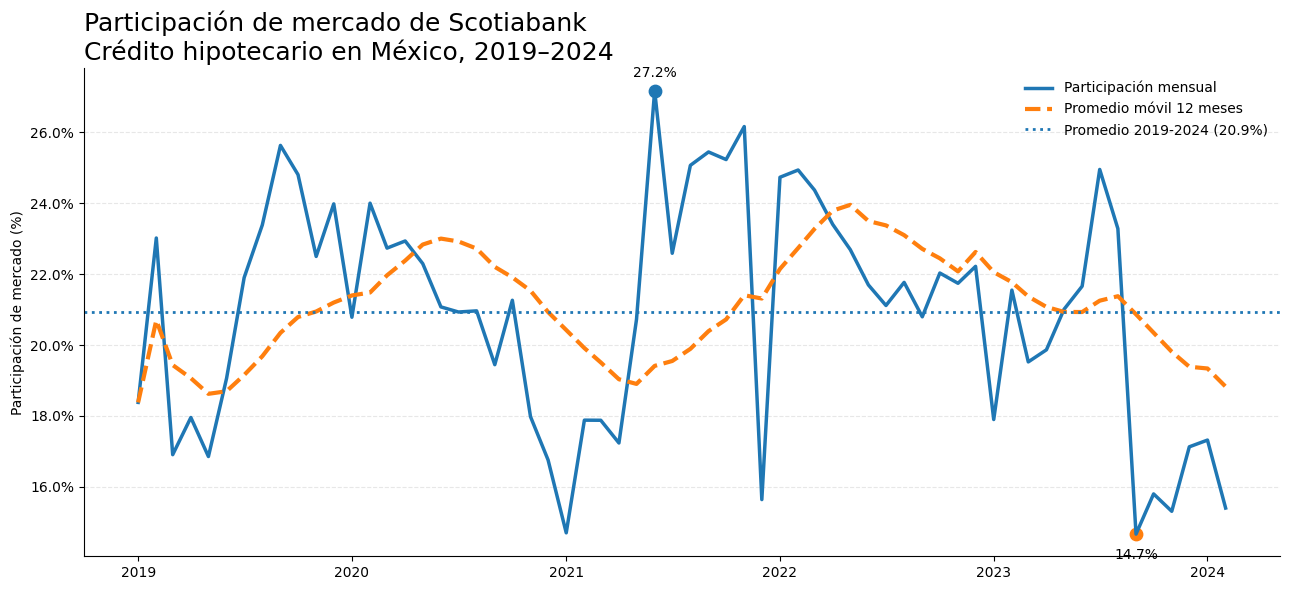

In [ ]:
## Generar grafica para una mejor visualización

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Asegurar formato fecha
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Ordenar cronológicamente
df = df.sort_values("Fecha")

# Promedio móvil de 12 meses
df["Tendencia"] = df["Part%"].rolling(
    window=12,
    min_periods=1
).mean()

promedio = df["Part%"].mean()

# Identificar máximo y mínimo
maximo = df.loc[df["Part%"].idxmax()]
minimo = df.loc[df["Part%"].idxmin()]

fig, ax = plt.subplots(figsize=(13,6))

# Serie original
ax.plot(
    df["Fecha"],
    df["Part%"],
    linewidth=2.5,
    label='Participación mensual'
)

# Tendencia suavizada
ax.plot(
    df["Fecha"],
    df["Tendencia"],
    linewidth=3,
    linestyle='--',
    label='Promedio móvil 12 meses'
)

# Promedio histórico
ax.axhline(
    promedio,
    linestyle=':',
    linewidth=2,
    label=f'Promedio 2019-2024 ({promedio:.1f}%)'
)

# Máximo
ax.scatter(maximo["Fecha"], maximo["Part%"], s=80)
ax.annotate(
    f'{maximo["Part%"]:.1f}%',
    (maximo["Fecha"], maximo["Part%"]),
    xytext=(0,10),
    textcoords='offset points',
    ha='center'
)

# Mínimo
ax.scatter(minimo["Fecha"], minimo["Part%"], s=80)
ax.annotate(
    f'{minimo["Part%"]:.1f}%',
    (minimo["Fecha"], minimo["Part%"]),
    xytext=(0,-18),
    textcoords='offset points',
    ha='center'
)

# Estilo ejecutivo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_title(
    "Participación de mercado de Scotiabank\nCrédito hipotecario en México, 2019–2024",
    fontsize=18,
    loc='left'
)

ax.set_ylabel("Participación de mercado (%)")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

**Resumen ejecutivo**

Entre 2019 y 2024, Scotiabank mantuvo una participación promedio de 20.9% del mercado hipotecario mexicano, posicionándose consistentemente como uno de los participantes relevantes del sector. Sin embargo, la evolución reciente muestra señales de pérdida de dinamismo comercial.

Scotiabank logró consolidar una participación relevante en el mercado hipotecario mexicano durante el periodo 2019–2022, alcanzando máximos superiores al 27%. No obstante, desde mediados de 2022 se observa una pérdida gradual de participación, situándose actualmente por debajo de su promedio histórico. La tendencia reciente sugiere la necesidad de evaluar si esta disminución responde a una decisión estratégica de priorizar rentabilidad y calidad de cartera, o bien a una pérdida de competitividad frente a otros participantes del mercado.

**Esto podría surgir de:**

* Menor agresividad comercial en originación hipotecaria.
* Mayor competencia por parte de otros bancos.
* Cambios en la estrategia de colocación o en las políticas de riesgo.
* Efectos del entorno macroeconómico y de las tasas de interés elevadas.

### **Top 5 participantes por participación de mercado:**

 Identifica los 5 bancos con mayor participación en el mercado de originación de hipotecas a nivel nacional.

 Voy a realizar dos analisis:
 1) Participación anual total del 2019 a 2024.
 2) Participación por año del 2019 a 2024

In [ ]:
from pyspark.sql.functions import col, sum, round, lit
from pyspark.sql.types import DecimalType

# Total del mercado (un solo valor)
mercado_total = Base.agg(
    sum("Monto_credito").cast(DecimalType(20,2)).alias("Monto_total")
).collect()[0]["Monto_total"]


# Monto por banco
banco_mes_total = Base.groupBy("Banco").agg(
    sum("Monto_credito").cast(DecimalType(20,2)).alias("Monto")
)

# Calcular participación usando constante
participacion_total = banco_mes_total.withColumn(
    "Part%",
    round(col("Monto") / lit(mercado_total) * 100, 4)
).select(
    "Banco",
    "Monto",
    "Part%"
).orderBy(col("Part%").desc())

participacion_total.show(5, truncate=False)


+-----------+---------------+-------+
|Banco      |Monto          |Part%  |
+-----------+---------------+-------+
|Banorte    |207729353334.01|24.9695|
|BBVA México|178346719837.16|21.4376|
|Scotiabank |174461286901.08|20.9706|
|HSBC       |126742981272.55|15.2347|
|Santander  |64462111821.66 |7.7485 |
+-----------+---------------+-------+
only showing top 5 rows


Los 5 bancos dominantes en el mercado de créditos hipotecarios del periodo 2019 a 2024 son: Banorte, con una participación porcentual de 24.94%, BBVa México con 21.43% y Scotiabank con una participación de 20.97%, respectivamente.



In [ ]:
## Visualización año con año

from pyspark.sql.functions import col, year, sum, round
from pyspark.sql.types import DecimalType

Base = Base.withColumn("Anio", year(col("Fecha")))

mercado_anio = Base.groupBy("Anio").agg(
    sum("Monto_credito").cast(DecimalType(20,2)).alias("Monto_total")
)

banco_anio = Base.groupBy("Anio", "Banco").agg(
    sum("Monto_credito").cast(DecimalType(20,2)).alias("Monto_banco")
)

participacion_anio = banco_anio.join(
    mercado_anio,
    on="Anio",
    how="left"
).withColumn(
    "Part%",
    round((col("Monto_banco") / col("Monto_total")) * 100, 4)
).orderBy(
    col("Part%").desc()
)

In [ ]:
#Aquí podemos hacer el filtro por año y los 5 bancos

print("Participación porcentual 2019")
participacion_anio.filter((col("Anio") == "2019")).show(5,truncate=False)

print("Participación porcentual 2020")
participacion_anio.filter((col("Anio") == "2020")).show(5,truncate=False)

print("Participación porcentual 2021")
participacion_anio.filter((col("Anio") == "2021")).show(5,truncate=False)

print("Participación porcentual 2022")
participacion_anio.filter((col("Anio") == "2022")).show(5,truncate=False)

print("Participación porcentual 2023")
participacion_anio.filter((col("Anio") == "2023")).show(5,truncate=False)

print("Participación porcentual 2024")
participacion_anio.filter((col("Anio") == "2024")).show(5,truncate=False)

Participación porcentual 2019
+----+-----------+--------------+---------------+-------+
|Anio|Banco      |Monto_banco   |Monto_total    |Part%  |
+----+-----------+--------------+---------------+-------+
|2019|Banorte    |31647500524.75|138282685320.27|22.8861|
|2019|Scotiabank |29528477029.84|138282685320.27|21.3537|
|2019|BBVA México|29305656998.62|138282685320.27|21.1926|
|2019|HSBC       |18591057475.00|138282685320.27|13.4442|
|2019|Banamex    |10321107064.00|138282685320.27|7.4638 |
+----+-----------+--------------+---------------+-------+
only showing top 5 rows
Participación porcentual 2020
+----+-----------+--------------+---------------+-------+
|Anio|Banco      |Monto_banco   |Monto_total    |Part%  |
+----+-----------+--------------+---------------+-------+
|2020|Banorte    |36120237348.07|143555779361.29|25.1611|
|2020|Scotiabank |29580855041.89|143555779361.29|20.6058|
|2020|BBVA México|28982064951.32|143555779361.29|20.1887|
|2020|HSBC       |18211578550.00|143555779361.

#### **4. Concentración geográfica:**

Encuentra los 5 estados donde la originación hipotecasde Scotiabank es más alta en comparación con el principal competidor.

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# ------------------------------------------------------------
# 1. Identificar al principal competidor de Scotiabank
#    (banco con mayor originación total excluyendo a Scotiabank)
# ------------------------------------------------------------
competidor_df = (Base
    .filter(F.col("Banco") != "Scotiabank")
    .groupBy("Banco")
    .agg(F.sum("Monto_credito").alias("total_originado"))
    .orderBy(F.col("total_originado").desc())
    .limit(1)
)

# Extraer el nombre del competidor como variable local
competidor_nombre = competidor_df.collect()[0]["Banco"]
print(f"Principal competidor: {competidor_nombre}")




Principal competidor: Banorte


In [ ]:
# ------------------------------------------------------------
# 2. Filtrar los datos solo para Scotiabank y ese competidor
# ------------------------------------------------------------
datos_filtrados = Base.filter(
    F.col("Banco").isin("Scotiabank", competidor_nombre)
)


# ------------------------------------------------------------
# 3. Agrupar por Estado y Banco, sumar Monto_credito
# ------------------------------------------------------------
origen_estado = (datos_filtrados
    .groupBy("Estado", "Banco")
    .agg(F.sum("Monto_credito").alias("monto_total"))
)

# ------------------------------------------------------------
# 4. Pivotear para tener columnas separadas por banco
# ------------------------------------------------------------
pivot_estado = (origen_estado
    .groupBy("Estado")
    .pivot("Banco", ["Scotiabank", competidor_nombre])
    .agg(F.sum("monto_total"))
    .na.fill(0)   # Llenar nulos con 0 (estados sin presencia de alguno)
)

# ------------------------------------------------------------
# 5. Calcular el indicador de comparación:
#    ratio = Scotiabank / Competidor (cuando ambos > 0)
# ------------------------------------------------------------
resultado = (pivot_estado
    .withColumn(
        "ratio_scotiabank_vs_competidor",
        F.when(
            (F.col(competidor_nombre) > 0) & (F.col("Scotiabank") > 0),
            F.col("Scotiabank") / F.col(competidor_nombre)
        ).otherwise(None)
    )
    .filter(F.col("ratio_scotiabank_vs_competidor").isNotNull())
    .orderBy(F.col("ratio_scotiabank_vs_competidor").desc())
    .limit(5)
)

# ------------------------------------------------------------
# 6. Mostrar los 5 estados con mayor ventaja relativa
# ------------------------------------------------------------
resultado.select(
    "Estado",
    F.format_number("Scotiabank", 4).alias("Originación_Scotiabank"),
    F.format_number(competidor_nombre, 4).alias(f"Originación_{competidor_nombre}"),
    F.round("ratio_scotiabank_vs_competidor", 2).alias("Ratio_Scotiabank_vs_Competidor")
).orderBy(F.col("Ratio_Scoti_vs_Banote").desc()).show(truncate=False)

+------------+----------------------+-------------------+------------------------------+
|Estado      |Originación_Scotiabank|Originación_Banorte|Ratio_Scotiabank_vs_Competidor|
+------------+----------------------+-------------------+------------------------------+
|TLAXCALA    |280,981,048.1600      |124,998,238.9300   |2.25                          |
|QUERÉTARO   |13,109,118,946.9700   |8,390,711,258.4500 |1.56                          |
|TABASCO     |1,057,804,088.7700    |799,549,578.8300   |1.32                          |
|CHIHUAHUA   |7,310,505,136.7100    |5,857,991,074.1300 |1.25                          |
|QUINTANA ROO|7,148,018,545.1700    |6,029,384,827.4700 |1.19                          |
+------------+----------------------+-------------------+------------------------------+



####  5. **BUSQUEDA DE OPORTUNIDADES**




a) Identifica segmentos de clientes potenciales desatendidos por Scotiabank (ie. Rangos de edad, nivel de ingreso, ubicación geográfica)

In [21]:
# ------------------------------------------------------------
# PASO 0: Definir buckets de Edad e Ingreso
# ------------------------------------------------------------
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window


# 0.1 Calcular percentiles de Ingreso (solo sobre registros NO nulos)

percentiles_ingreso = Base.filter(
    F.col("Ingreso_mensual_bruto").isNotNull()
).approxQuantile(
    col="Ingreso_mensual_bruto",
    probabilities=[0.25, 0.5, 0.75],
    relativeError=0.01  # Precisión aceptable para grandes volúmenes
)

p25_ingreso, p50_ingreso, p75_ingreso = percentiles_ingreso

print(f"Percentiles de Ingreso (Mercado Total): P25={p25_ingreso}, P50={p50_ingreso}, P75={p75_ingreso}")

Percentiles de Ingreso (Mercado Total): P25=8012.0, P50=15324.0, P75=44341.44


In [27]:
# 0.2 Crear columna 'bucket_ingreso' con categorías dinámicas
df = Base.withColumn(
    "bucket_ingreso",
    F.when(F.col("Ingreso_mensual_bruto").isNull(), "Sin_dato_ingreso")
    .when(F.col("Ingreso_mensual_bruto") < p25_ingreso, "Bajo")
    .when((F.col("Ingreso_mensual_bruto") >= p25_ingreso) & (F.col("Ingreso_mensual_bruto") < p50_ingreso), "Medio-Bajo")
    .when((F.col("Ingreso_mensual_bruto") >= p50_ingreso) & (F.col("Ingreso_mensual_bruto") < p75_ingreso), "Medio-Alto")
    .when(F.col("Ingreso_mensual_bruto") >= p75_ingreso, "Alto")
    .otherwise("Otro")
)

# 0.3 Crear columna 'bucket_edad' con rangos fijos
df = df.withColumn(
    "bucket_edad",
    F.when(F.col("Edad_acred").isNull(), "Sin_dato_edad")
    .when((F.col("Edad_acred") >= 18) & (F.col("Edad_acred") <= 25), "18-25")
    .when((F.col("Edad_acred") >= 26) & (F.col("Edad_acred") <= 35), "26-35")
    .when((F.col("Edad_acred") >= 36) & (F.col("Edad_acred") <= 45), "36-45")
    .when((F.col("Edad_acred") >= 46) & (F.col("Edad_acred") <= 55), "46-55")
    .when((F.col("Edad_acred") >= 56) & (F.col("Edad_acred") <= 65), "56-65")
    .when(F.col("Edad_acred") > 65, "65+")
    .otherwise("Otro")
)

# Verificación de distribución
df.groupBy("bucket_edad", "bucket_ingreso").count().orderBy("count").show(100)


+-----------+--------------+------+
|bucket_edad|bucket_ingreso| count|
+-----------+--------------+------+
|        65+|          Bajo|   426|
|        65+|    Medio-Bajo|   531|
|        65+|    Medio-Alto|  3014|
|      18-25|          Alto|  4236|
|        65+|          Alto|  5840|
|      18-25|    Medio-Alto|  7109|
|      56-65|    Medio-Bajo|  9971|
|      56-65|          Bajo| 11993|
|      18-25|          Bajo| 18230|
|      18-25|    Medio-Bajo| 18885|
|      56-65|    Medio-Alto| 20503|
|      56-65|          Alto| 31836|
|      46-55|    Medio-Bajo| 42386|
|      46-55|          Bajo| 51956|
|      46-55|    Medio-Alto| 53906|
|      46-55|          Alto| 62204|
|      26-35|          Alto| 68702|
|      36-45|    Medio-Bajo| 79324|
|      36-45|    Medio-Alto| 81189|
|      36-45|          Bajo| 84994|
|      36-45|          Alto| 89604|
|      26-35|          Bajo| 93341|
|      26-35|    Medio-Alto|101769|
|      26-35|    Medio-Bajo|106626|
+-----------+--------------+

In [33]:
# ------------------------------------------------------------
#Agregar Totales del Mercado y de Scotiabank
# ------------------------------------------------------------

# 1. Agregación A: Totales del mercado (todos los bancos)
total_mercado = df.groupBy("bucket_edad", "bucket_ingreso").agg(
    F.sum("Monto_credito").alias("total_monto"),
    F.count("*").alias("total_conteo")
)


# 2. Agregación B: Totales de Scotiabank
scotiabank = df.filter(F.col("Banco") == "Scotiabank").groupBy("bucket_edad", "bucket_ingreso").agg(
    F.sum("Monto_credito").alias("scotia_monto"),
    F.count("*").alias("scotia_conteo")
)

scotiabank.orderBy("scotia_conteo").show(15)

+-----------+--------------+--------------------+-------------+
|bucket_edad|bucket_ingreso|        scotia_monto|scotia_conteo|
+-----------+--------------+--------------------+-------------+
|        65+|          Bajo|          4576598.83|            5|
|      18-25|          Bajo|           5969984.7|            7|
|        65+|    Medio-Bajo|1.0893924830000002E7|           16|
|      56-65|          Bajo|4.8234463480000004E7|           34|
|      18-25|    Medio-Bajo|5.5650016269999996E7|           67|
|      46-55|          Bajo|      1.6097075833E8|          117|
|      56-65|    Medio-Bajo|      1.6503891398E8|          204|
|      36-45|          Bajo|2.7556855522999996E8|          204|
|      26-35|          Bajo|2.4879089025999996E8|          204|
|        65+|    Medio-Alto|3.1919861942999995E8|          329|
|      18-25|          Alto| 8.342154011700001E8|          364|
|      46-55|    Medio-Bajo| 2.968485167000001E8|          401|
|      18-25|    Medio-Alto| 5.159692495

In [34]:
# ------------------------------------------------------------
#  Unir y calcular Shares
# ------------------------------------------------------------

# 3. Unir agregaciones (left join para incluir segmentos donde Scotiabank no opera)
segmentos = total_mercado.join(
    scotiabank,
    on=["bucket_edad", "bucket_ingreso"],
    how="left"
).fillna({"scotia_monto": 0, "scotia_conteo": 0})

# Calcular el Share de Scotiabank dentro de cada segmento (evitando división por cero)
segmentos = segmentos.withColumn(
    "share_monto_segmento",
    F.when(F.col("total_monto") == 0, F.lit(None))
    .otherwise(F.col("scotia_monto") / F.col("total_monto"))
).withColumn(
    "share_conteo_segmento",
    F.when(F.col("total_conteo") == 0, F.lit(None))
    .otherwise(F.col("scotia_conteo") / F.col("total_conteo"))
)

# 4. Calcular Share Global de Scotiabank (benchmark)
global_monto_total = df.agg(F.sum("Monto_credito")).collect()[0][0]
global_conteo_total = df.count()

scotia_monto_total = df.filter(F.col("Banco") == "Scotiabank").agg(F.sum("Monto_credito")).collect()[0][0]
scotia_conteo_total = df.filter(F.col("Banco") == "Scotiabank").count()

share_global_monto = scotia_monto_total / global_monto_total if global_monto_total > 0 else 0
share_global_conteo = scotia_conteo_total / global_conteo_total if global_conteo_total > 0 else 0

print(f"Share Global Scotiabank (Monto): {share_global_monto:.2%}")
print(f"Share Global Scotiabank (Conteo): {share_global_conteo:.2%}")

Share Global Scotiabank (Monto): 20.97%
Share Global Scotiabank (Conteo): 8.91%


In [36]:
# ------------------------------------------------------------
# Calcular IPR y extraer Top 5 de oportunidades
# ------------------------------------------------------------

# 5. Calcular IPR (usando monto como métrica principal)
segmentos = segmentos.withColumn(
    "IPR_monto",
    F.when(F.col("share_monto_segmento").isNull(), F.lit(None))
    .otherwise(F.col("share_monto_segmento") / F.lit(share_global_monto))
).withColumn(
    "IPR_conteo",
    F.when(F.col("share_conteo_segmento").isNull(), F.lit(None))
    .otherwise(F.col("share_conteo_segmento") / F.lit(share_global_conteo))
)

# Calcular el porcentaje que representa cada segmento del mercado total
segmentos = segmentos.withColumn(
    "pct_del_mercado",
    F.col("total_monto") / F.lit(global_monto_total)
)

# 6. Filtrar subatendidos (IPR < 0.8), con tamaño significativo (> 0.5% del mercado) y ordenar
oportunidades = segmentos.filter(
    (F.col("IPR_monto") < 0.8) &
    (F.col("IPR_monto") > 0) &  # Excluir donde no hay presencia (IPR=0) para no distraer
    (F.col("pct_del_mercado") > 0.005)  # Mínimo 0.5% del mercado total para considerar relevante
).orderBy(
    F.col("total_monto").desc(),
    F.col("IPR_monto").asc()
)

# Seleccionar Top 5
top_5_oportunidades = oportunidades.select(
    "bucket_edad",
    "bucket_ingreso",
    F.round("total_monto", 2).alias("monto_total_segmento (MM)"),
    F.round("scotia_monto", 2).alias("monto_scotia_segmento (MM)"),
    F.round(F.col("share_monto_segmento") * 100, 2).alias("share_scotia_%"),
    F.round(F.col("IPR_monto") * 100, 2).alias("IPR_%"),
    F.round(F.col("pct_del_mercado") * 100, 2).alias("%_del_mercado_total")
).limit(5)

top_5_oportunidades = oportunidades.select(
    "bucket_edad",
    "bucket_ingreso",
    F.round("total_monto", 2).cast(DecimalType(20,2)).alias("monto_total_segmento (MM)"),
    F.round("scotia_monto", 2).cast(DecimalType(20,2)).alias("monto_scotia_segmento (MM)"),
    F.round(F.col("share_monto_segmento") * 100, 2).alias("share_scotia_%"),
    F.round(F.col("IPR_monto") * 100, 2).alias("IPR_%"),
    F.round(F.col("pct_del_mercado") * 100, 2).alias("%_del_mercado_total")
).limit(5)
# Mostrar resultados
print("\n--- TOP 5 PERFILES DE CLIENTE IDEAL (SUBATENDIDOS POR SCOTIABANK) ---")
top_5_oportunidades.show(truncate=False)


--- TOP 5 PERFILES DE CLIENTE IDEAL (SUBATENDIDOS POR SCOTIABANK) ---
+-----------+--------------+-------------------------+--------------------------+--------------+-----+-------------------+
|bucket_edad|bucket_ingreso|monto_total_segmento (MM)|monto_scotia_segmento (MM)|share_scotia_%|IPR_%|%_del_mercado_total|
+-----------+--------------+-------------------------+--------------------------+--------------+-----+-------------------+
|46-55      |Medio-Alto    |32752245308.25           |5154880851.71             |15.74         |75.05|3.94               |
|26-35      |Medio-Bajo    |14925851061.30           |1052967935.37             |7.05          |33.64|1.79               |
|65+        |Alto          |12682874998.32           |2037879946.55             |16.07         |76.62|1.52               |
|36-45      |Medio-Bajo    |11965517759.08           |688948614.82              |5.76          |27.46|1.44               |
|26-35      |Bajo          |11353409649.06           |248790890.26  

In [42]:

# 1. Extraer las combinaciones exactas del Top 5
# ------------------------------------------------------------
top_pairs = [tuple(row) for row in top_5_oportunidades.select("bucket_edad", "bucket_ingreso").collect()]

print("Segmentos a profilar:")
for p in top_pairs:
    print(f"  - Edad: {p[0]}, Ingreso: {p[1]}")




Segmentos a profilar:
  - Edad: 46-55, Ingreso: Medio-Alto
  - Edad: 26-35, Ingreso: Medio-Bajo
  - Edad: 65+, Ingreso: Alto
  - Edad: 36-45, Ingreso: Medio-Bajo
  - Edad: 26-35, Ingreso: Bajo


In [46]:
# ------------------------------------------------------------
# 2. Filtrar el DataFrame original SOLO para esos segmentos
# ------------------------------------------------------------
pairs_df = spark.createDataFrame(top_pairs, ["bucket_edad", "bucket_ingreso"])
df_filtered = df.join(pairs_df, on=["bucket_edad", "bucket_ingreso"], how="inner")

print(f"Registros en los segmentos objetivo: {df_filtered.count()}")

Registros en los segmentos objetivo: 339037


In [48]:
# ------------------------------------------------------------
# 3. Preparar las columnas de cruce (manejo de nulos)
# ------------------------------------------------------------
df_clean = df_filtered.withColumn(
    "Estado_clean", F.coalesce(F.col("Estado"), F.lit("No_especificado"))
).withColumn(
    "Destino_clean", F.coalesce(F.col("Destino_credito"), F.lit("No_especificado"))
).withColumn(
    "Tipo_comp_clean", F.coalesce(F.col("Tipo_comprobacion"), F.lit("No_especificado"))
)

# ------------------------------------------------------------
# 4. Agregación A: Totales del mercado para el sub-nicho
# ------------------------------------------------------------
total_mercado_fino = df_clean.groupBy(
    "bucket_edad", "bucket_ingreso", "Estado_clean", "Destino_clean", "Tipo_comp_clean"
).agg(
    F.sum("Monto_credito").alias("total_monto"),
    F.count("*").alias("total_conteo")
)

# ------------------------------------------------------------
# 5. Agregación B: Totales de Scotiabank para el sub-nicho
# ------------------------------------------------------------
scotia_fino = df_clean.filter(
    F.col("Banco") == "Scotiabank"
).groupBy(
    "bucket_edad", "bucket_ingreso", "Estado_clean", "Destino_clean", "Tipo_comp_clean"
).agg(
    F.sum("Monto_credito").alias("scotia_monto"),
    F.count("*").alias("scotia_conteo")
)

# ------------------------------------------------------------
# 6. Unir y calcular métricas del sub-nicho
# ------------------------------------------------------------
segmentos_finos = total_mercado_fino.join(
    scotia_fino,
    on=["bucket_edad", "bucket_ingreso", "Estado_clean", "Destino_clean", "Tipo_comp_clean"],
    how="left"
).fillna({"scotia_monto": 0, "scotia_conteo": 0})

# Calcular Share dentro del sub-nicho
segmentos_finos = segmentos_finos.withColumn(
    "share_monto_subnicho",
    F.when(F.col("total_monto") == 0, F.lit(None))
    .otherwise(F.col("scotia_monto") / F.col("total_monto"))
)



In [49]:
# ------------------------------------------------------------
# 7. Calcular el IPR para el sub-nicho
# ------------------------------------------------------------
# Usamos el share_global_monto que calculamos en el paso anterior (global del banco)
segmentos_finos = segmentos_finos.withColumn(
    "IPR_subnicho",
    F.when(F.col("share_monto_subnicho").isNull(), F.lit(None))
    .otherwise(F.col("share_monto_subnicho") / F.lit(share_global_monto))
)

# Calcular qué porcentaje del mercado TOTAL (no solo del segmento) representa este sub-nicho
segmentos_finos = segmentos_finos.withColumn(
    "pct_del_mercado_total",
    F.col("total_monto") / F.lit(global_monto_total)
)

# ------------------------------------------------------------
# 8. Filtrar y ordenar para encontrar los TOP micro-nichos
# ------------------------------------------------------------
# Criterios de filtro:
# - IPR < 0.8 (subatendido)
# - IPR > 0 (que tenga al menos algo de presencia, para no perseguir fantasmas)
# - Tamaño mínimo: al menos 0.1% del mercado total (para que sea relevante)
oportunidades_finas = segmentos_finos.filter(
    (F.col("IPR_subnicho") < 0.8) &
    (F.col("IPR_subnicho") > 0) &
    (F.col("pct_del_mercado_total") > 0.001)  # 0.1% del mercado total
).orderBy(
    F.col("total_monto").desc(),
    F.col("IPR_subnicho").asc()
)


In [50]:
# Seleccionar el Top 10 de micro-nichos (puedes cambiarlo a 20 si quieres más)
top_micro_nichos = oportunidades_finas.select(
    F.col("bucket_edad").alias("Rango_Edad"),
    F.col("bucket_ingreso").alias("Nivel_Ingreso"),
    F.col("Estado_clean").alias("Estado"),
    F.col("Destino_clean").alias("Destino_Credito"),
    F.col("Tipo_comp_clean").alias("Tipo_Comprobacion"),
    F.round(F.col("total_monto") / 1e9, 2).alias("Mercado_Total_(MM_MXN)"),  # En miles de millones
    F.round(F.col("scotia_monto") / 1e9, 2).alias("Scotiabank_(MM_MXN)"),
    F.round(F.col("share_monto_subnicho") * 100, 2).alias("Share_Scotiabank_%"),
    F.round(F.col("IPR_subnicho") * 100, 2).alias("IPR_%"),
    F.round(F.col("pct_del_mercado_total") * 100, 4).alias("%_del_Mercado_Total")
).limit(10)

# ------------------------------------------------------------
# 9. Mostrar resultados
# ------------------------------------------------------------
print("\n--- TOP 10 MICRO-NICHOS (SUBATENDIDOS) DENTRO DE LOS 5 SEGMENTOS PRIORITARIOS ---")
top_micro_nichos.show(truncate=False)


--- TOP 10 MICRO-NICHOS (SUBATENDIDOS) DENTRO DE LOS 5 SEGMENTOS PRIORITARIOS ---
+----------+-------------+----------------+-----------------------------+-----------------+----------------------+-------------------+------------------+-----+-------------------+
|Rango_Edad|Nivel_Ingreso|Estado          |Destino_Credito              |Tipo_Comprobacion|Mercado_Total_(MM_MXN)|Scotiabank_(MM_MXN)|Share_Scotiabank_%|IPR_%|%_del_Mercado_Total|
+----------+-------------+----------------+-----------------------------+-----------------+----------------------+-------------------+------------------+-----+-------------------+
|46-55     |Medio-Alto   |NUEVO LEÓN      |Adquisición de Vivienda Nueva|Asalariado       |2.21                  |0.24               |10.78             |51.42|0.265              |
|26-35     |Bajo         |NUEVO LEÓN      |Adquisición de Vivienda Nueva|Asalariado       |2.2                   |0.04               |1.6               |7.62 |0.2641             |
|26-35     |Medio

**b)**  Explora regiones geográficas con tasas de interés promedio más altas donde Scotiabank podría ajustar su tasa de interés.


In [18]:
from pyspark.sql import functions as F

# ------------------------------------------------------------
# 1. Calcular la tasa de mercado por estado (todos los bancos)
#    Tasa_mercado = Σ (tasa * monto) / Σ monto
# ------------------------------------------------------------
tasa_mercado_estado = (Base
    .withColumn("ingresos_intereses", F.col("tasa_ponderada") * F.col("Monto_credito"))
    .groupBy("Estado")
    .agg(
        F.sum("Monto_credito").alias("monto_total_mercado"),
        F.sum("ingresos_intereses").alias("ingresos_totales_mercado")
    )
    .withColumn(
        "tasa_mercado",
        F.col("ingresos_totales_mercado") / F.col("monto_total_mercado")
    )
    .drop("ingresos_totales_mercado")

)

# ------------------------------------------------------------
# 2. Calcular la tasa ponderada de Scotiabank por estado
# ------------------------------------------------------------
tasa_scotiabank_estado = (Base
    .filter(F.col("Banco") == "Scotiabank")
    .withColumn("ingresos_intereses", F.col("tasa_ponderada") * F.col("Monto_credito"))
    .groupBy("Estado")
    .agg(
        F.sum("Monto_credito").alias("monto_scotiabank"),
        F.sum("ingresos_intereses").alias("ingresos_scotiabank")
    )
    .withColumn(
        "tasa_scotiabank",
        F.col("ingresos_scotiabank") / F.col("monto_scotiabank")
    )
    .drop("ingresos_scotiabank")
)


# ------------------------------------------------------------
# 3. Unión y filtrado de valores nulos
# ------------------------------------------------------------
comparativa_tasas = (tasa_mercado_estado
    .join(tasa_scotiabank_estado, "Estado", "left")
    # Rellenar nulos de Scotiabank con 0 (estados sin presencia de Scotiabank)
    .na.fill(0, subset=["tasa_scotiabank", "monto_scotiabank"])
    # Eliminar filas con Estado nulo
    .filter(F.col("Estado").isNotNull())
    .withColumn(
        "diferencia_tasa",
        F.col("tasa_scotiabank") - F.col("tasa_mercado")
    )
)


# ------------------------------------------------------------
# 4. Top 5 estados con mayor tasa de mercado
#    y mostrar la comparación con Scotiabank
# ------------------------------------------------------------
top_5_tasas_altas = (comparativa_tasas
    .orderBy(F.col("tasa_mercado").desc())
    .limit(5)
)

top_5_tasas_altas.select(
    "Estado",
    F.round("tasa_mercado", 4).alias("Tasa_mercado"),
    F.round("tasa_scotiabank", 4).alias("Tasa_Scotiabank"),
    F.round("diferencia_tasa", 4).alias("Diferencia (Scotiabank - Mercado)")
).show(truncate=False)



+----------+------------+---------------+---------------------------------+
|Estado    |Tasa_mercado|Tasa_Scotiabank|Diferencia (Scotiabank - Mercado)|
+----------+------------+---------------+---------------------------------+
|TLAXCALA  |11.1148     |10.3826        |-0.7322                          |
|CAMPECHE  |10.581      |10.3131        |-0.2679                          |
|CHIAPAS   |10.5094     |10.4848        |-0.0246                          |
|DURANGO   |10.4449     |10.303         |-0.1419                          |
|TAMAULIPAS|10.4389     |10.2974        |-0.1414                          |
+----------+------------+---------------+---------------------------------+

